In [1]:
# Ensure the parent directory is in sys.path
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Testing Monte Carlo Library with SDEs and Generators

This notebook is designed to test the integration of stochastic differential equations (SDEs), random generators, and the Monte Carlo library. The goal is to simulate paths, compute payoffs, and analyze results using the Monte Carlo framework.

## Import Required Libraries

We will import the necessary libraries, including NumPy, matplotlib, and the Monte Carlo library.

In [2]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from pricer.mc_engine import MCEngine
from pricer.basic_mapping import BasicMapping
from random_generator.normal import NormalBoxMuller
from random_generator.linear_congruential import LinearCongruential
from sde.bs_euler_1d import BSEuler1D
from payoff.vanilla_payoff import VanillaCallPayoff

## Define the Stochastic Differential Equation (SDE)

We will define the SDE using mathematical functions for the drift and diffusion terms.

In [3]:
# Define the SDE

def drift(x, t):
    """Drift term: μ(X_t, t)."""
    return 0.05 * x

def diffusion(x, t):
    """Diffusion term: σ(X_t, t)."""
    return 0.2 * x

## Implement the Monte Carlo Simulation

We will use the Monte Carlo library to simulate multiple paths of the SDE and compute the payoff.

## Generate and Visualize Results

We will plot the simulated paths and analyze the results using statistical methods.

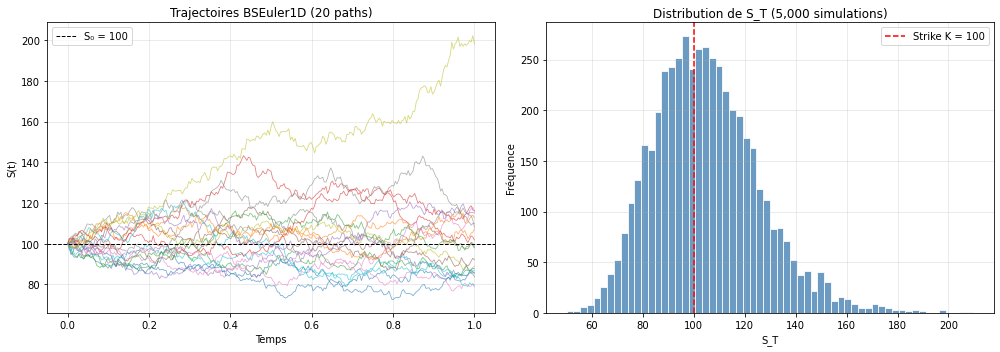

Moyenne S_T : 104.97
Théorique   : 105.13  (S₀·e^(r·T))


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Paramètres ---
T            = 1.0
nb_steps     = 252
nb_vis_paths = 20
time_grid    = np.linspace(0, T, nb_steps + 1)

# --- Process pour la visualisation ---
uniform_vis = LinearCongruential(seed=123)
normal_vis  = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_vis)
proc_vis    = BSEuler1D(generator=normal_vis, spot=100, rate=0.05, vol=0.2)

# --- Récupérer les trajectoires via MCEngine.simulate_paths() ---
engine_vis = MCEngine()
paths = engine_vis.simulate_paths(proc_vis, nb_paths=5000, T=T, nb_steps=nb_steps)
# paths[i][dim] = List[float] pour la trajectoire i, dimension dim

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1 : trajectoires ---
for i in range(nb_vis_paths):
    values = paths[i][0]          # dimension 0 (1D)
    axes[0].plot(time_grid, values, alpha=0.6, linewidth=0.8)

axes[0].axhline(100, color='k', linestyle='--', linewidth=1, label='S₀ = 100')
axes[0].set_title(f"Trajectoires BSEuler1D ({nb_vis_paths} paths)")
axes[0].set_xlabel("Temps")
axes[0].set_ylabel("S(t)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2 : distribution des valeurs terminales ---
terminal_values = [paths[i][0][-1] for i in range(len(paths))]

axes[1].hist(terminal_values, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(100, color='red', linestyle='--', linewidth=1.5, label='Strike K = 100')
axes[1].set_title(f"Distribution de S_T ({len(paths):,} simulations)")
axes[1].set_xlabel("S_T")
axes[1].set_ylabel("Fréquence")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Moyenne S_T : {np.mean(terminal_values):.2f}")
print(f"Théorique   : {100 * np.exp(0.05 * T):.2f}  (S₀·e^(r·T))")

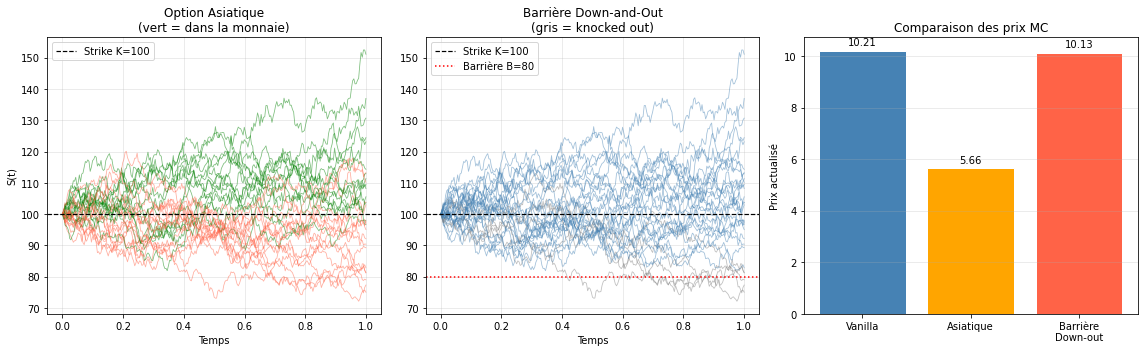

Prix Vanilla   : 10.2122
Prix Asiatique : 5.6593
Prix Barrière  : 10.1295


In [5]:
# --- Visualisation de payoffs path-dépendants ---

T        = 1.0
nb_steps = 252
K        = 100    # strike
B        = 80     # barrière down-and-out
r        = 0.05
time_grid = np.linspace(0, T, nb_steps + 1)

# Simuler les trajectoires
uniform_pd = LinearCongruential(seed=99)
normal_pd  = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_pd)
proc_pd    = BSEuler1D(generator=normal_pd, spot=100, rate=r, vol=0.2)

engine_pd = MCEngine()
paths = engine_pd.simulate_paths(proc_pd, nb_paths=5000, T=T, nb_steps=nb_steps)
# paths[i][0] = List[float] — chemin complet S(t₀), ..., S(T)

# --- Calcul des payoffs ---
discount = np.exp(-r * T)
vanilla_payoffs  = []
asian_payoffs    = []
barrier_payoffs  = []

for i in range(len(paths)):
    traj   = paths[i][0]
    s_T    = traj[-1]
    s_mean = sum(traj) / len(traj)
    s_min  = min(traj)

    vanilla_payoffs.append(max(s_T - K, 0))
    asian_payoffs.append(max(s_mean - K, 0))
    barrier_payoffs.append(0.0 if s_min <= B else max(s_T - K, 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1 : trajectoires Asiatique (vert = dans la monnaie) ---
for i in range(30):
    traj  = paths[i][0]
    color = 'green' if asian_payoffs[i] > 0 else 'tomato'
    axes[0].plot(time_grid, traj, alpha=0.5, linewidth=0.8, color=color)
axes[0].axhline(K, color='k', linestyle='--', linewidth=1.2, label=f'Strike K={K}')
axes[0].set_title("Option Asiatique\n(vert = dans la monnaie)")
axes[0].set_xlabel("Temps")
axes[0].set_ylabel("S(t)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2 : trajectoires Barrière (gris = knocked out) ---
for i in range(30):
    traj        = paths[i][0]
    knocked_out = min(traj) <= B
    color       = 'grey' if knocked_out else 'steelblue'
    axes[1].plot(time_grid, traj, alpha=0.5, linewidth=0.8, color=color)
axes[1].axhline(K, color='k',   linestyle='--', linewidth=1.2, label=f'Strike K={K}')
axes[1].axhline(B, color='red', linestyle=':',  linewidth=1.5, label=f'Barrière B={B}')
axes[1].set_title("Barrière Down-and-Out\n(gris = knocked out)")
axes[1].set_xlabel("Temps")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Plot 3 : comparaison des prix ---
labels = ['Vanilla', 'Asiatique', 'Barrière\nDown-out']
prices = [
    discount * np.mean(vanilla_payoffs),
    discount * np.mean(asian_payoffs),
    discount * np.mean(barrier_payoffs),
]
bars = axes[2].bar(labels, prices, color=['steelblue', 'orange', 'tomato'], edgecolor='white')
for bar, val in zip(bars, prices):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + 0.2, f"{val:.2f}", ha='center', fontsize=10)
axes[2].set_title("Comparaison des prix MC")
axes[2].set_ylabel("Prix actualisé")
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Prix Vanilla   : {prices[0]:.4f}")
print(f"Prix Asiatique : {prices[1]:.4f}")
print(f"Prix Barrière  : {prices[2]:.4f}")

In [6]:
# Monte Carlo simulation using the proper payoff class

# Use VanillaCallPayoff which correctly handles List[SinglePath]
payoff = VanillaCallPayoff(strike=100)

# Define process parameters
initial_value = 100
rate = 0.0
volatility = 0.2

# Random generator
uniform_gen = LinearCongruential(seed=42)
normal_gen = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_gen)

# Define process using BSEuler1D
process = BSEuler1D(
    generator=normal_gen,
    spot=initial_value,
    rate=rate,
    vol=volatility
)

# Run Monte Carlo simulation with Euler scheme
engine = MCEngine()
result = engine.price_with_scheme(
    payoff=payoff,
    process=process,
    nb_paths=10000,
    T=1.0,
    nb_steps=252,
    rate=rate,
    scheme="euler",
    multi_asset=False,
)

print("Option Price (Euler Scheme):", result.price)

Option Price (Euler Scheme): 7.850440240444982
